# Reinforcement Learning 
## OpenAI Gym & Dynamic Programming (Policy Iteration and Value Iteration)

### 🎯 Learning Objectives
- Get familiar with the OpenAI Gym environment (`FrozenLake-v1`).
- Understand how MDP components (S, A, P, R, γ) are represented in Gym.
- Implement **Policy Iteration** and **Value Iteration** algorithms.
- Visualize and compare the resulting policies.


In [2]:
import os                       # 导入 os 模块,用于设置环境变量
import gymnasium as gym         # 导入 gymnasium 强化学习环境库
import numpy as np              # 导入 numpy,用于数值计算(矩阵/数组)
import matplotlib.pyplot as plt # 导入 matplotlib 绘图库
os.environ["SDL_VIDEODRIVER"] = "dummy"   # 设置 SDL 用无界面驱动,避免渲染时弹出窗口
from IPython.display import clear_output  # 导入清空输出函数,用于动画逐帧刷新

# 创建 FrozenLake(冰湖)环境,is_slippery=False 表示非光滑(确定性)环境,便于理解
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode='rgb_array')
n_states = env.observation_space.n   # 状态空间大小:4×4 网格共 16 个状态
n_actions = env.action_space.n       # 动作空间大小:上/下/左/右共 4 个动作
P = env.unwrapped.P                  # 取出环境的转移概率字典 P(转移动态)

print("Number of states:", n_states)   # 打印状态数量
print("Number of actions:", n_actions) # 打印动作数量


Number of states: 16
Number of actions: 4


Display the environment in the notebook

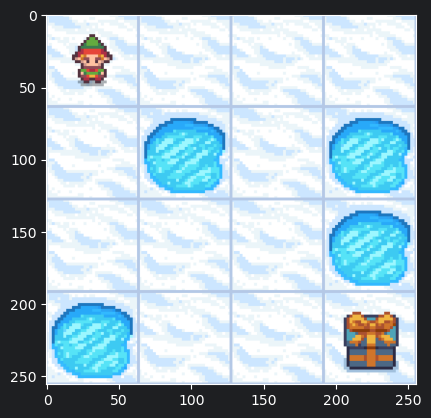

In [3]:
observation = env.reset(seed=42)   # 重置环境到初始状态,seed=42 保证结果可复现
plt.imshow(env.render())           # 渲染当前画面并显示,可视化初始的冰湖网格


OpenAI Gym gives us access to the **transition probability table** `P`.

- `P[state][action]` → list of tuples `(prob, next_state, reward, done)`.
- This is exactly what we need for **dynamic programming** algorithms.


In [4]:
# 查看起始状态(状态 0)的所有转移信息
P[0]   # P[0] 是字典,键为动作(0~3),值为 [(转移概率, 下一状态, 奖励, 是否结束), ...]


{0: [(1.0, 0, 0, False)],
 1: [(1.0, 4, 0, False)],
 2: [(1.0, 1, 0, False)],
 3: [(1.0, 0, 0, False)]}

In [5]:
for s in range(n_states):            # 遍历所有 16 个状态 s
    print(f"\nState {s}:")           # 打印当前状态编号
    for a in range(n_actions):       # 遍历所有 4 个动作 a
        print(f"  Action {a}:")      # 打印当前动作编号
        for prob, next_s, reward, done in P[s][a]:   # 遍历 (s,a) 的每一种转移结果
            print(f"    → Next state {next_s}, Reward {reward}, Done {done}, Prob {prob:.2f}")   # 打印下一状态/奖励/是否结束/概率



State 0:
  Action 0:
    → Next state 0, Reward 0, Done False, Prob 1.00
  Action 1:
    → Next state 4, Reward 0, Done False, Prob 1.00
  Action 2:
    → Next state 1, Reward 0, Done False, Prob 1.00
  Action 3:
    → Next state 0, Reward 0, Done False, Prob 1.00

State 1:
  Action 0:
    → Next state 0, Reward 0, Done False, Prob 1.00
  Action 1:
    → Next state 5, Reward 0, Done True, Prob 1.00
  Action 2:
    → Next state 2, Reward 0, Done False, Prob 1.00
  Action 3:
    → Next state 1, Reward 0, Done False, Prob 1.00

State 2:
  Action 0:
    → Next state 1, Reward 0, Done False, Prob 1.00
  Action 1:
    → Next state 6, Reward 0, Done False, Prob 1.00
  Action 2:
    → Next state 3, Reward 0, Done False, Prob 1.00
  Action 3:
    → Next state 2, Reward 0, Done False, Prob 1.00

State 3:
  Action 0:
    → Next state 2, Reward 0, Done False, Prob 1.00
  Action 1:
    → Next state 7, Reward 0, Done True, Prob 1.00
  Action 2:
    → Next state 3, Reward 0, Done False, Prob 1.00
  

In [6]:
import time                        # 导入 time 模块,用于让动画停顿以便观察
from IPython.display import clear_output   # 导入清空输出函数,用于逐帧刷新动画

def run_episode(env, policy, max_steps=20, render_sleep=1):
    # 作用:在环境中按给定策略运行一个回合(episode),并实时渲染动画
    state = env.reset()[0]   # 重置环境,得到初始状态(reset() 返回 (观察, info) 元组,取第一个元素)
    done = False             # done 标志位,记录回合是否结束(掉入洞或到达终点)
    for step in range(max_steps):   # 最多走 max_steps 步,防止无限循环

        #print(f"Step {step+1}")    # (可选)打印当前步数,默认被注释掉

        clear_output(wait=True)     # 清空上一次的画面输出,准备绘制新一帧
        plt.imshow(env.render())    # 渲染当前状态,把冰湖画面画出来
        plt.show()                  # 显示渲染出的图像

        if done:                    # 如果上一个动作已经让回合结束
            if reward == 1.0:       # 判断结束时的奖励是否为 1(即是否成功到达终点)
                print("✅ Reached the goal!")   # 奖励为 1:打印"到达终点"
            else:                   # 否则说明掉进了冰洞里
                print("💀 Fell into a hole!")   # 打印"掉入洞中"
            break                   # 回合已结束,跳出循环

        action = np.argmax(policy[state])   # 按策略选择当前状态下的动作(取概率最大的动作)
        state, reward, done, truncated, info = env.step(action)   # 执行动作,得到新状态/奖励/是否结束等信息

        time.sleep(render_sleep)    # 停顿 render_sleep 秒,让动画看起来是逐步进行的


In [7]:
def create_random_policy(n_states, n_actions, seed=None):
    # 作用:创建一个随机策略——每个状态下随机给出各动作概率,并归一化到和为 1
    rng = np.random.default_rng(seed)  # 创建随机数生成器(给定 seed 则结果可复现)
    policy = np.zeros((n_states, n_actions))   # 初始化策略矩阵为全 0,形状 (状态数, 动作数)
    for s in range(n_states):                  # 遍历所有状态 s
        probs = rng.random(n_actions)          # 为该状态随机生成 n_actions 个正数,作为动作概率
        probs /= probs.sum()                   # 归一化,使该状态下所有动作概率之和为 1
        policy[s] = probs                      # 把该状态的概率分布写入策略矩阵第 s 行
    return policy                              # 返回构造好的随机策略

# 示例:用固定种子 42 创建一个随机策略
random_policy = create_random_policy(n_states, n_actions, seed=42) ## 该随机策略会掉进洞里
#random_policy = create_random_policy(n_states, n_actions, seed=43) ## 该策略会一直向上走
#random_policy = create_random_policy(n_states, n_actions, seed=2025) ## 该策略会一直向左走


In [8]:
random_policy   # 直接显示随机策略矩阵(16 行 × 4 列,每行是该状态下各动作的概率)


array([[0.27952757, 0.15850851, 0.31009744, 0.25186648],
       [0.03598671, 0.37280129, 0.29084395, 0.30036805],
       [0.06828857, 0.24006978, 0.19764694, 0.49399471],
       [0.3012545 , 0.3849574 , 0.20746663, 0.10632147],
       [0.26692276, 0.03071537, 0.39834053, 0.30402133],
       [0.25469674, 0.11911103, 0.32612798, 0.30006426],
       [0.52467735, 0.13119821, 0.31459806, 0.02952638],
       [0.06051493, 0.26790327, 0.29210823, 0.37947357],
       [0.24040612, 0.27333901, 0.34645582, 0.13979905],
       [0.08647887, 0.31664059, 0.1510363 , 0.44584424],
       [0.19152649, 0.36481582, 0.30680254, 0.13685514],
       [0.35984468, 0.34795646, 0.16753426, 0.1246646 ],
       [0.66292692, 0.13574549, 0.19417641, 0.00715118],
       [0.26787368, 0.22631914, 0.24004244, 0.26576475],
       [0.35797308, 0.4436414 , 0.10904738, 0.08933814],
       [0.27063762, 0.19074774, 0.22886516, 0.30974948]])

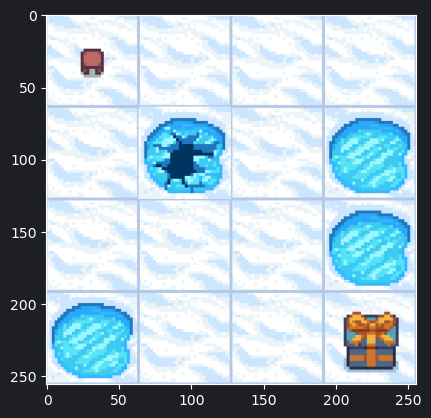

💀 Fell into a hole!


In [9]:
run_episode(env, random_policy, max_steps=10, render_sleep=0.5)   # 用随机策略跑一个回合,观察它(大概率)掉进洞里


## Step 1: Policy Evaluation
We evaluate a given policy by iteratively computing the value function:
$V_{k+1}(s) = \sum_a \pi(a|s) \big[\sum_{r} P(r|s,a)r + \gamma\sum_{s'}V_{k}(s')P(s'|s,a) \big]$

$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s',r} P(s',r|s,a)\big[(r + \gamma V_{k}(s') \big]$

In [10]:
def policy_evaluation(policy, P, gamma=0.9, theta=1e-6):
    """策略评估:迭代计算给定策略 π 下的状态价值函数 V(s)。

    根据贝尔曼期望方程:
    V(s) = Σ_a π(a|s) · Σ_{s',r} P(s',r|s,a) · [ r + γ·V(s') ]
    不断迭代更新 V,直到相邻两轮的最大变化量 delta 小于阈值 theta(即收敛)。

    参数:
        policy: 形状为 (n_states, n_actions) 的策略矩阵,policy[s][a] = π(a|s)
        P:      环境转移概率表,P[s][a] = [(prob, next_s, reward, done), ...]
        gamma:  折扣因子 γ
        theta:  收敛阈值,当 delta < theta 时停止迭代
    返回:
        V: 收敛后的状态价值函数(长度为 n_states 的数组)
    """
    V = np.zeros(n_states)   # 把所有状态的价值初始化为 0
    while True:              # 不断迭代,直到价值函数收敛
        delta = 0            # 记录本轮迭代中价值的最大变化量
        for s in range(n_states):          # 遍历所有状态 s
            v = 0                          # 用于累加状态 s 的新价值
            for a, action_prob in enumerate(policy[s]):   # 遍历所有动作 a 及其策略概率 π(a|s)
                for prob, next_s, reward, done in P[s][a]:  # 遍历 (s,a) 转移的每种可能结果
                    # 贝尔曼期望更新:策略概率 × 转移概率 × (即时奖励 + 折扣 × 下一状态价值)
                    v += action_prob * prob * (reward + gamma * V[next_s])
            delta = max(delta, abs(v - V[s]))   # 更新本轮的最大变化量(新旧价值之差)
            V[s] = v                            # 用新计算的价值覆盖旧价值
        if delta < theta:   # 若最大变化量已小于阈值,说明价值函数已收敛
            break           # 跳出循环,结束评估
    return V                # 返回收敛后的价值函数


# 示例:评估一个"均匀随机"策略(每个状态下每个动作的概率都相等)
random_policy = np.ones([n_states, n_actions]) / n_actions   # 均匀随机策略:每行都是 1/n_actions
V_random = policy_evaluation(random_policy, P)               # 对这个随机策略做策略评估
V_random.reshape(4, 4)                                       # 把 16 个状态的价值重塑成 4×4 网格,便于观察

array([[0.00447571, 0.00422165, 0.01006621, 0.00411784],
       [0.00672128, 0.        , 0.02633356, 0.        ],
       [0.01867586, 0.0576069 , 0.10697187, 0.        ],
       [0.        , 0.13038299, 0.39149011, 0.        ]])

## Step 2: Policy Improvement
We improve a policy by acting greedily with respect to the current value function.
$q_{\pi}(s,a)=\sum_{r}[P(r|s,a)r+\gamma\sum_{s'}V_{\pi}(s')P(s'|s,a)]$

$q_{\pi}(s,a)=\sum_{s',r}P(s',r|s,a)[r+\gamma V_{\pi}(s')]$

We greedily choose the action which will gain the largest action value.
$\pi'=argmax_{a}q_{\pi}(s,a)$

In [11]:
def policy_improvement(V, P, gamma=0.9):
    """策略改进:根据当前价值函数 V,贪心地选出每个状态的最优动作,得到新策略。

    先计算动作价值函数:
    q(s,a) = Σ_{s',r} P(s',r|s,a) · [ r + γ·V(s') ]
    然后对每个状态 s,选择 q(s,a) 最大的那个动作,构造一个确定性(贪心)策略。

    参数:
        V:     当前的状态价值函数(长度为 n_states 的数组)
        P:     环境转移概率表
        gamma: 折扣因子 γ
    返回:
        policy: 改进后的确定性策略(one-hot 形式,每行只有一个 1)
    """
    policy = np.zeros([n_states, n_actions])   # 初始化新策略为全 0(确定性策略)
    for s in range(n_states):                  # 遍历所有状态 s
        q_values = np.zeros(n_actions)         # 存储状态 s 下每个动作的 q 值
        for a in range(n_actions):             # 遍历所有动作 a
            for prob, next_s, reward, done in P[s][a]:   # 遍历 (s,a) 转移的每种可能结果
                # 累加动作价值:转移概率 × (即时奖励 + 折扣 × 下一状态价值)
                q_values[a] += prob * (reward + gamma * V[next_s])
        best_a = np.argmax(q_values)           # 选出 q 值最大的动作(贪心)
        policy[s] = np.eye(n_actions)[best_a]  # 用 one-hot 向量表示确定性动作(只有 best_a 位置为 1)
    return policy                              # 返回改进后的策略

## Step 3: Policy Iteration
Alternate between **policy evaluation** and **policy improvement** until convergence.

$\pi_{0} →(PE)→ V_{\pi_0} →(PI)→ \pi_{1} →(PE)→ V_{\pi_1} →(PI)→ \pi_{2} →...$

In [12]:
def policy_iteration(P, gamma=0.9, theta=1e-6):
    """策略迭代:反复在"策略评估"和"策略改进"之间交替,直到策略不再变化。

    迭代流程:
    π0 →(策略评估)→ V_π0 →(策略改进)→ π1 →(策略评估)→ V_π1 → ... → 直到 π 收敛

    参数:
        P:     环境转移概率表
        gamma: 折扣因子 γ
        theta: 策略评估时的收敛阈值
    返回:
        policy: 收敛后的最优策略
        V:      最优策略对应的价值函数
    """
    policy = np.ones([n_states, n_actions]) / n_actions   # 初始化为"均匀随机"策略(每个动作概率相等)
    while True:                                           # 反复迭代,直到策略收敛
        V = policy_evaluation(policy, P, gamma, theta)    # 1. 策略评估:计算当前策略的价值函数 V
        new_policy = policy_improvement(V, P, gamma)      # 2. 策略改进:基于 V 贪心改进出新的策略
        if (new_policy == policy).all():   # 若新策略与旧策略完全相同(策略已稳定不变)
            break                          # 说明策略已收敛,跳出循环
        policy = new_policy                # 否则用新策略继续下一轮迭代
    return policy, V                       # 返回最优策略和对应的价值函数


# 运行策略迭代,得到最优策略和最优价值函数
pi_policy, pi_value = policy_iteration(P)   # 在非光滑(确定性)环境中求最优策略
pi_value.reshape(4, 4)                      # 把价值函数重塑成 4×4 网格显示

array([[0.59049, 0.6561 , 0.729  , 0.6561 ],
       [0.6561 , 0.     , 0.81   , 0.     ],
       [0.729  , 0.81   , 0.9    , 0.     ],
       [0.     , 0.9    , 1.     , 0.     ]])

In [13]:
pi_policy   # 显示策略迭代得到的最优策略(one-hot 形式,每行只有一个 1,表示最优动作)


array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.]])

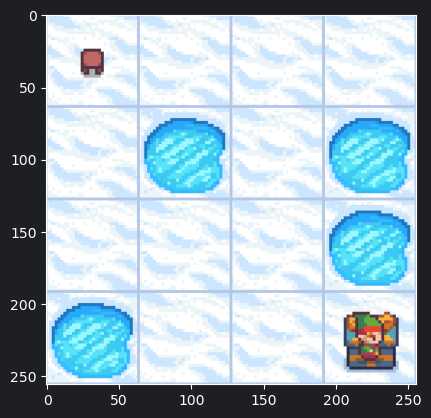

✅ Reached the goal!


In [14]:
run_episode(env, pi_policy, max_steps=10, render_sleep=0.5)   # 用策略迭代得到的最优策略跑一个回合,观察它到达终点


## Step 4: Value Iteration
Instead of full policy evaluation, update value estimates directly:
$
V_{k+1}(s) = \max_a \sum_{s',r} P(s',r|s,a) [r + \gamma V_k(s')]
$

#### TODO 1: Please implement the code for the value iteration algorithm, compute the optimal policy and run the episode.

In [15]:
def value_iteration(P, gamma=0.9, theta=1e-6):
    """价值迭代:直接对最优价值函数做贝尔曼最优方程迭代,一步到位求出最优策略。

    贝尔曼最优方程:
    V(s) = max_a Σ_{s',r} P(s',r|s,a) · [ r + γ·V(s') ]
    每轮直接取所有动作中的最大值更新 V,收敛后再从 V 提取贪心策略。

    参数:
        P:     环境转移概率表
        gamma: 折扣因子 γ
        theta: 收敛阈值
    返回:
        policy: 从最优价值函数提取出的最优策略
        V:      最优价值函数
    """
    V = np.zeros(n_states)   # 把所有状态的价值初始化为 0

    while True:              # 不断迭代,直到价值函数收敛
        delta = 0            # 记录本轮迭代的最大变化量
        for s in range(n_states):            # 遍历所有状态 s
            q_values = np.zeros(n_actions)   # 存储状态 s 下每个动作的 q 值
            for a in range(n_actions):       # 遍历所有动作 a
                for prob, next_s, reward, done in P[s][a]:   # 遍历 (s,a) 转移的每种可能结果
                    # 累加动作价值:转移概率 × (即时奖励 + 折扣 × 下一状态价值)
                    q_values[a] += prob * (reward + gamma * V[next_s])
            best_value = np.max(q_values)    # 取所有动作中最大的 q 值(贝尔曼最优更新)
            delta = max(delta, abs(best_value - V[s]))   # 更新本轮最大变化量
            V[s] = best_value                # 用最优值更新状态 s 的价值

        if delta < theta:   # 若最大变化量小于阈值,说明价值函数已收敛
            break           # 跳出循环

    # 从最优价值函数中提取(贪心)最优策略
    policy = np.zeros((n_states, n_actions))   # 初始化策略为全 0
    for s in range(n_states):                  # 遍历所有状态 s
        q_values = np.zeros(n_actions)         # 重新计算状态 s 下每个动作的 q 值
        for a in range(n_actions):             # 遍历所有动作 a
            for prob, next_s, reward, done in P[s][a]:   # 遍历转移的每种可能结果
                # 累加 q 值:转移概率 × (即时奖励 + 折扣 × 下一状态价值)
                q_values[a] += prob * (reward + gamma * V[next_s])

        best_a = np.argmax(q_values)           # 选出 q 值最大的动作(贪心)
        policy[s] = np.eye(n_actions)[best_a]  # 用 one-hot 向量表示该确定性动作

    return policy, V   # 返回最优策略和最优价值函数

In [16]:
vi_policy, vi_value = value_iteration(P)   # 用价值迭代求最优策略和最优价值函数
vi_value.reshape(4, 4)                     # 把 16 个状态的价值重塑成 4×4 网格显示


array([[0.59049, 0.6561 , 0.729  , 0.6561 ],
       [0.6561 , 0.     , 0.81   , 0.     ],
       [0.729  , 0.81   , 0.9    , 0.     ],
       [0.     , 0.9    , 1.     , 0.     ]])

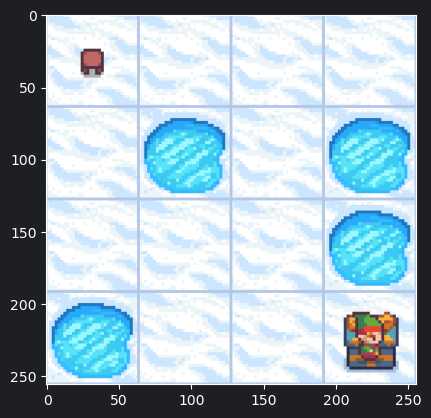

✅ Reached the goal!


In [17]:
run_episode(env, vi_policy, max_steps=10, render_sleep=0.5)   # 用价值迭代得到的最优策略跑一个回合,观察它到达终点

#### TODO 2: Please use the slippery environment, and compute the optimal policy.

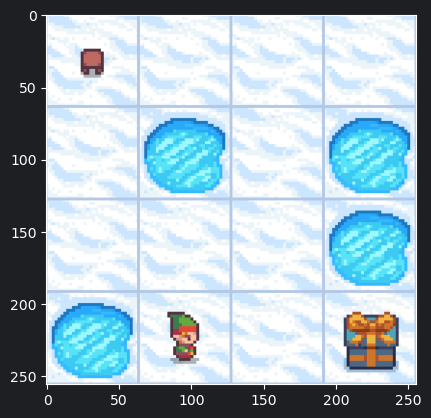

In [18]:
# 创建光滑(is_slippery=True)的 FrozenLake 环境:执行动作时会有概率滑向随机方向
env_slippery = gym.make("FrozenLake-v1", is_slippery=True, render_mode='rgb_array')

P_slippery = env_slippery.unwrapped.P   # 取出光滑环境的转移概率表 P

# 用价值迭代算法在光滑环境上计算最优策略和最优价值函数
vi_policy_slippery, vi_value_slippery = value_iteration(P_slippery)

print("\nSlippery Environment - Optimal Value Function:")
print(vi_value_slippery.reshape(4, 4))   # 把 16 个状态的价值重塑成 4×4 网格显示

# 在光滑环境中运行一次回合,观察智能体能否到达终点
print("\nRunning episode in slippery environment:")
run_episode(env_slippery, vi_policy_slippery, max_steps=20, render_sleep=0.5)

#### TODO 3: Please compare the optimal policy between the slippery and unslippery environment, and discuss why the agent sometimes fails in the slippery environment, and how the value functions differ between the two cases.


COMPARISON BETWEEN SLIPPERY AND NON-SLIPPERY ENVIRONMENTS

Optimal Policy Comparison:
State | Non-Slippery | Slippery
-----------------------------------
    0 | DOWN         | LEFT    
    1 | RIGHT        | UP      
    2 | DOWN         | LEFT    
    3 | LEFT         | UP      
    4 | DOWN         | LEFT    
    5 | LEFT         | LEFT    
    6 | DOWN         | LEFT    
    7 | LEFT         | LEFT    
    8 | RIGHT        | UP      
    9 | DOWN         | DOWN    
   10 | DOWN         | LEFT    
   11 | LEFT         | LEFT    
   12 | LEFT         | LEFT    
   13 | RIGHT        | RIGHT   
   14 | RIGHT        | DOWN    
   15 | LEFT         | LEFT    

Number of states with different policies: 9
States with different policies: [ 0  1  2  3  4  6  8 10 14]

Value Function Comparison:
State | Non-Slippery Value | Slippery Value | Difference
-------------------------------------------------------
    0 |            0.5905 |         0.0689 |     0.5216
    1 |            0.6561 |   

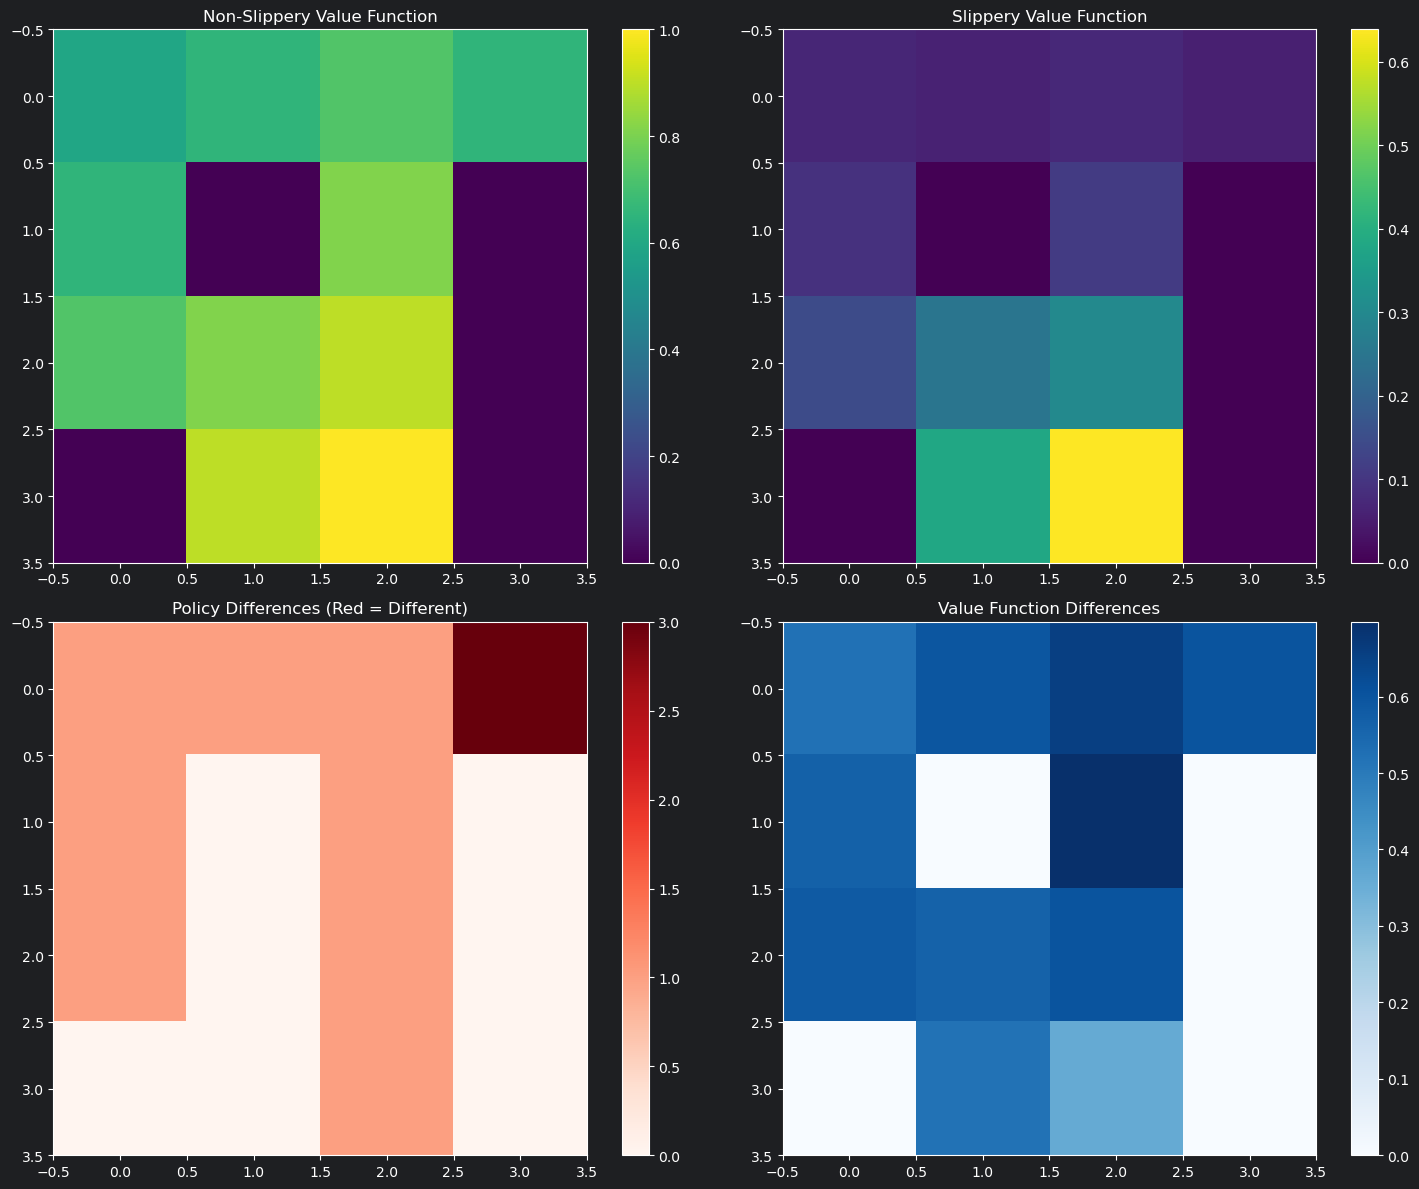

In [19]:
print("\n" + "=" * 60)                                    # 打印分隔线(60 个等号)
print("COMPARISON BETWEEN SLIPPERY AND NON-SLIPPERY ENVIRONMENTS")   # 标题:对比光滑与非光滑环境
print("=" * 60)                                          # 打印分隔线


# 比较两个环境得到的最优策略
def get_deterministic_policy(policy):
    """把(可能随机的)策略矩阵转换为确定性的动作编号。

    对每个状态,取概率最大的那个动作作为该状态的确定性动作。
    参数:
        policy: 形状 (n_states, n_actions) 的策略矩阵
    返回:
        长度为 n_states 的数组,每个元素是该状态的最优动作编号
    """
    return np.argmax(policy, axis=1)   # axis=1 表示沿"动作"维度取最大值对应的下标

non_slippery_actions = get_deterministic_policy(vi_policy)   # 非光滑环境的最优动作序列
slippery_actions = get_deterministic_policy(vi_policy_slippery)   # 光滑环境的最优动作序列

action_names = {0: "LEFT", 1: "DOWN", 2: "RIGHT", 3: "UP"}   # 动作编号 → 名称的映射(便于阅读)

print("\nOptimal Policy Comparison:")                     # 打印"最优策略对比"标题
print("State | Non-Slippery | Slippery")                  # 打印表格表头
print("-" * 35)                                           # 打印分隔线
for s in range(n_states):                                 # 遍历所有状态 s
    # 逐状态打印:状态号 | 非光滑环境动作 | 光滑环境动作
    print(f"{s:5} | {action_names[non_slippery_actions[s]]:12} | {action_names[slippery_actions[s]]:8}")

# 找出两个环境中策略不同的状态
different_states = np.where(non_slippery_actions != slippery_actions)[0]   # 用布尔比较找出动作不同的状态下标
print(f"\nNumber of states with different policies: {len(different_states)}")   # 打印策略不同的状态数量
if len(different_states) > 0:                                # 若存在策略不同的状态
    print("States with different policies:", different_states)   # 打印这些状态的下标

# 比较两个环境的价值函数
print("\nValue Function Comparison:")                     # 打印"价值函数对比"标题
print("State | Non-Slippery Value | Slippery Value | Difference")   # 打印表头
print("-" * 55)                                           # 打印分隔线
for s in range(n_states):                                 # 遍历所有状态 s
    diff = np.abs(vi_value[s] - vi_value_slippery[s])     # 计算该状态在两种环境下价值的绝对差值
    # 逐状态打印:状态号 | 非光滑价值 | 光滑价值 | 差值
    print(f"{s:5} | {vi_value[s]:17.4f} | {vi_value_slippery[s]:14.4f} | {diff:10.4f}")

# 分析与讨论
print("\n" + "=" * 60)                                    # 打印分隔线
print("ANALYSIS AND DISCUSSION")                          # 打印"分析与讨论"标题
print("=" * 60)                                           # 打印分隔线

print("""
为什么在光滑环境中智能体有时会失败：
1. 随机性影响：在光滑环境中，智能体的动作有1/3的概率会滑向其他方向，这增加了不确定性
2. 风险规避策略：光滑环境中的最优策略会避开危险区域（洞），选择更安全的路径
3. 价值函数差异：光滑环境中的价值函数值通常较低，因为考虑到随机性带来的风险
策略差异的原因：
1. 非光滑环境：智能体可以采取最短路径，因为动作是确定性的
2. 光滑环境：智能体需要避开靠近洞的边缘状态，防止滑入洞中
3. 保守策略：光滑环境中，智能体可能选择远离危险的动作，即使这些动作不是最短路径
价值函数差异：
1. 非光滑环境：价值函数值较高，因为成功概率接近100%
2. 光滑环境：价值函数值较低，因为考虑到随机性导致的失败概率
3. 状态价值：靠近洞的状态在光滑环境中价值显著降低，反映了更高的风险
""")   # 以上是多行字符串,内容是分析讨论的文字说明

# 可视化两种环境的差异
fig, axes = plt.subplots(2, 2, figsize=(15, 12))   # 创建 2×2 的四个子图,总尺寸 15×12

# 左上:非光滑环境的价值函数热力图
im1 = axes[0, 0].imshow(vi_value.reshape(4, 4), cmap='viridis')   # 画非光滑价值函数热力图(颜色映射 viridis)
axes[0, 0].set_title('Non-Slippery Value Function')               # 设置子图标题
plt.colorbar(im1, ax=axes[0, 0])                                  # 为该子图添加颜色条

# 右上:光滑环境的价值函数热力图
im2 = axes[0, 1].imshow(vi_value_slippery.reshape(4, 4), cmap='viridis')   # 画光滑价值函数热力图
axes[0, 1].set_title('Slippery Value Function')                  # 设置子图标题
plt.colorbar(im2, ax=axes[0, 1])                                 # 添加颜色条

# 左下:策略差异热力图(动作不同的状态标红)
policy_diff = np.abs(non_slippery_actions.reshape(4, 4) - slippery_actions.reshape(4, 4))   # 计算动作差异(不同则为非 0)
im3 = axes[1, 0].imshow(policy_diff, cmap='Reds')                # 用红色系画出策略差异
axes[1, 0].set_title('Policy Differences (Red = Different)')     # 设置子图标题
plt.colorbar(im3, ax=axes[1, 0])                                 # 添加颜色条

# 右下:价值函数差异热力图
value_diff = np.abs(vi_value.reshape(4, 4) - vi_value_slippery.reshape(4, 4))   # 计算价值函数逐状态差值的绝对值
im4 = axes[1, 1].imshow(value_diff, cmap='Blues')                # 用蓝色系画出价值差异
axes[1, 1].set_title('Value Function Differences')               # 设置子图标题
plt.colorbar(im4, ax=axes[1, 1])                                 # 添加颜色条

plt.tight_layout()   # 自动调整子图之间的间距,避免标签重叠
plt.show()           # 显示整个图形